In [ ]:
import io
import math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

## Loading dataset

In [ ]:
!wget -O exoplanets.csv https://stuff.it-mil-1.linodeobjects.com/exoplanets.csv > /dev/null 2>&1
csv_filename = f'exoplanets.csv'
df = pd.read_csv(csv_filename, comment='#')

In [ ]:
# extract all the comment lines from the file for reference
with open(csv_filename, 'r') as f:
    lines = f.readlines()
    comment_lines = [line for line in lines if line.startswith('#')]

print(''.join(comment_lines))

# This file was produced by the NASA Exoplanet Archive  http://exoplanetarchive.ipac.caltech.edu
# Wed Mar 11 03:14:31 2026
#
# COLUMN pl_name:        Planet Name
# COLUMN hostname:       Host Name
# COLUMN default_flag:   Default Parameter Set
# COLUMN sy_snum:        Number of Stars
# COLUMN sy_pnum:        Number of Planets
# COLUMN discoverymethod: Discovery Method
# COLUMN disc_year:      Discovery Year
# COLUMN disc_facility:  Discovery Facility
# COLUMN soltype:        Solution Type
# COLUMN pl_controv_flag: Controversial Flag
# COLUMN pl_refname:     Planetary Parameter Reference
# COLUMN pl_orbper:      Orbital Period [days]
# COLUMN pl_orbpererr1:  Orbital Period Upper Unc. [days]
# COLUMN pl_orbpererr2:  Orbital Period Lower Unc. [days]
# COLUMN pl_orbperlim:   Orbital Period Limit Flag
# COLUMN pl_orbsmax:     Orbit Semi-Major Axis [au]
# COLUMN pl_orbsmaxerr1: Orbit Semi-Major Axis Upper Unc. [au]
# COLUMN pl_orbsmaxerr2: Orbit Semi-Major Axis Lower Unc. [au]
# COLUMN pl_o

In [ ]:
PLANET_NAME = 'pl_name'
HOST_NAME = 'hostname'
DISCOVERY_METHOD = 'discoverymethod'
DISCOVERY_FACILITY = 'disc_facility'
DISCOVERY_YEAR = 'disc_year'

TOTAL_STARS = 'sy_snum'
TOTAL_PLANETS = 'sy_pnum'
PLANET_ORBITAL_PERIOD = 'pl_orbper'
PLANET_SEMI_MAJOR_AXIS = 'pl_orbsmax'
PLANET_DISTANCE = 'sy_dist'

PLANET_MASS = 'pl_bmassj'
PLANET_RADIUS = 'pl_radj'

STELLAR_MASS = 'st_mass'
STELLAR_RADIUS = 'st_rad'
STELLAR_GRAVITY = 'st_logg'
STELLAR_TEMPERATURE = 'st_teff'

DEFAULT_FLAG = 'default_flag'
CONTROVERSIAL_FLAG = 'pl_controv_flag'

PLANET_ORBITAL_PERIOD_ERROR_BRACKET = 'pl_orbperbkt'

RELEASE_DATE = 'releasedate'

In [ ]:
df[PLANET_ORBITAL_PERIOD_ERROR_BRACKET] = df['pl_orbpererr1'] - df['pl_orbpererr2']

## Test hypothesis on the dataset structure
Right now we know:
  * mostly three discovery methods have been used on the planets (`Transit` is the most common)
  * when planets have been measured multiple times, the same facility and discovery method has been used
  * every planet has a single default flag measurement
  * there are some rows with both `DEFAULT_FLAG` and `CONTROVERSIAL_FLAG` set

In [ ]:
def check_assumptions(df):
    for name, local_df in df.groupby(PLANET_NAME):
        stars = local_df[TOTAL_STARS]
        planets = local_df[TOTAL_PLANETS]
        discovery_method = local_df[DISCOVERY_METHOD]
        discovery_facility = local_df[DISCOVERY_FACILITY]

        assert(len(local_df[TOTAL_STARS].unique()) == 1)
        assert(len(local_df[TOTAL_PLANETS].unique()) == 1)
        assert(len(local_df[DISCOVERY_METHOD].unique()) == 1)
        assert(len(local_df[DISCOVERY_FACILITY].unique()) == 1)

        assert(np.sum(local_df[DEFAULT_FLAG]) == 1)

check_assumptions(df)

In [ ]:
def find_controversial_planets(df):
  controversial_planets = []

  for name, local_df in df.groupby(PLANET_NAME):
    default_pos = np.argwhere(local_df[DEFAULT_FLAG] == 1)[0][0]

    if local_df[CONTROVERSIAL_FLAG].iloc[default_pos] == 1:
      controversial_planets.append(name)

  return controversial_planets

controv_planets = find_controversial_planets(df)
controv_planet_count = len(controv_planets)
total_planet_count = len(df[PLANET_NAME].unique())
controv_ratio = controv_planet_count / total_planet_count

print(f'Controversial planets [{controv_planet_count}/{total_planet_count}], ratio = {controv_ratio}%')

Controversial planets [49/6138], ratio = 0.007983056370153145%


In [ ]:
# I decide to not further investigate those controversial planets
# since they are only 49 (.07%)
df = df[~df[PLANET_NAME].isin(controv_planets)]
assert(find_controversial_planets(df) == [])

## General distribution of target columns

In [ ]:
# counts the discovery methods percentage
discovery_method_count = {
    discovery_method: len(local_df)/len(df)
    for discovery_method, local_df in df.groupby(DISCOVERY_METHOD)
}

for method, count in sorted(discovery_method_count.items(), key=lambda x: x[1], reverse=True):
    print(f'{method}: {count:.2f}%')

Transit: 0.90%
Radial Velocity: 0.07%
Microlensing: 0.02%
Imaging: 0.00%
Transit Timing Variations: 0.00%
Eclipse Timing Variations: 0.00%
Orbital Brightness Modulation: 0.00%
Pulsar Timing: 0.00%
Astrometry: 0.00%
Pulsation Timing Variations: 0.00%
Disk Kinematics: 0.00%


In [ ]:
CHOSEN_DISCOVERY_METHODS = [
    'Transit',
    'Radial Velocity',
    'Microlensing',
]

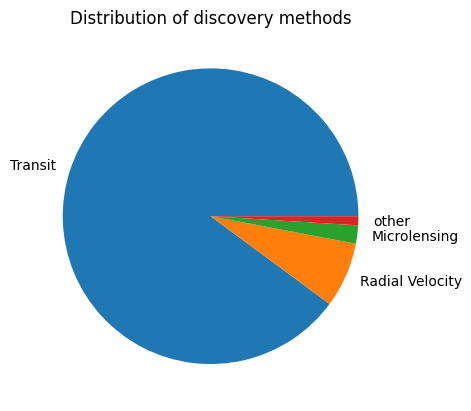

In [ ]:
def discovery_pie(df):
    labels = CHOSEN_DISCOVERY_METHODS.copy()
    labels.append('other')

    sizes = np.zeros(len(labels))

    for i, method in enumerate(CHOSEN_DISCOVERY_METHODS):
        sizes[i] = len(df[df[DISCOVERY_METHOD] == method])

    sizes[-1] = len(df) - np.sum(sizes)

    plt.title("Distribution of discovery methods")
    plt.pie(sizes, labels=labels)
    plt.show()

discovery_pie(df)

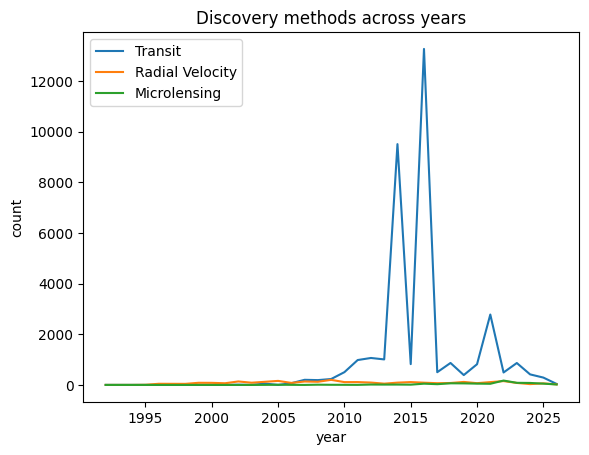

In [ ]:
discovery_method_count = {method: [] for method in CHOSEN_DISCOVERY_METHODS}
all_years = []

for year, local_df in df.groupby(DISCOVERY_YEAR):
    all_years.append(year)

    for method, arr in discovery_method_count.items():
        arr.append(np.sum((local_df[DISCOVERY_METHOD] == method)))

plt.title("Discovery methods across years")
plt.xlabel("year")
plt.ylabel("count")

for method, count in discovery_method_count.items():
    plt.plot(all_years, np.array(count)+0.1, label=method)

plt.legend()
plt.show()

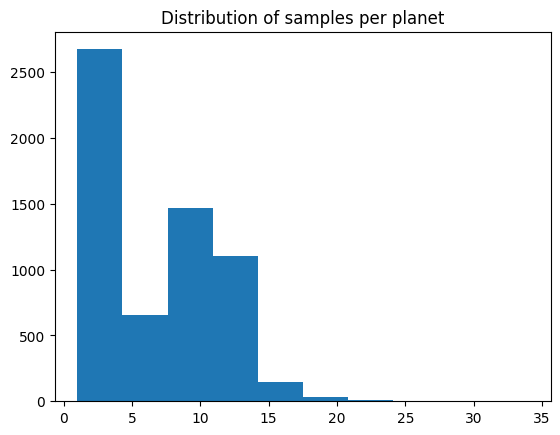

In [ ]:
planet_counts = [len(local_df) for name, local_df in df.groupby(PLANET_NAME)]

plt.title("Distribution of samples per planet")
plt.hist(planet_counts)
plt.show()

# Solving the aggregation problem
In simple terms, we need a dataset with only one row per planet. The simplest solution is to take the only row with `DEFAULT_FLAG=1`. All analyses will be based on the aggregated dataset.

In [ ]:
def aggregate_dataset(df: pd.DataFrame, method: str = 'default') -> pd.DataFrame:
  result = None
  if method == 'default':
    result = df.iloc[np.where(df[DEFAULT_FLAG] == 1)]
  elif method == 'first':
    # take the first row for every planet
    result = df.groupby(PLANET_NAME).first()
  elif method == 'median':
    # some columns are not numeric, so we need to conserve them
    result = pd.DataFrame(
        df.groupby(PLANET_NAME).median(numeric_only=True)
    )
  elif method == 'average':
    result = pd.DataFrame(
        df.groupby(PLANET_NAME).mean(numeric_only=True)
    )
  elif method == 'weighted_avg':
    pass
  else:
    raise ValueError(f'Unknown aggregation method {method}')

  # add a column that tells the number of samples per planet
  # result['sample_count'] = 0

  return result

In [ ]:
aggregated_dataset = aggregate_dataset(df, method='average')
aggregated_dataset

,default_flag,sy_snum,sy_pnum,disc_year,pl_controv_flag,pl_orbper,pl_orbpererr1,pl_orbpererr2,pl_orbperlim,pl_orbsmax,...,sy_vmag,sy_vmagerr1,sy_vmagerr2,sy_kmag,sy_kmagerr1,sy_kmagerr2,sy_gaiamag,sy_gaiamagerr1,sy_gaiamagerr2,pl_orbperbkt
pl_name,,,,,,,,,,,,,,,,,,,,,
11 Com b,0.333333,2.0,1.0,2007.0,0.0,324.620000,0.190000,-0.185000,0.0,1.226000,...,4.72307,0.023,-0.023,2.282,0.346,-0.346,4.44038,0.003848,-0.003848,0.375000
11 UMi b,0.333333,1.0,1.0,2009.0,0.0,516.219985,3.225000,-3.225000,0.0,1.526667,...,5.01300,0.005,-0.005,1.939,0.270,-0.270,4.56216,0.003903,-0.003903,6.450000
14 And b,0.333333,1.0,1.0,2008.0,0.0,186.300000,0.170000,-0.175000,0.0,0.761667,...,5.23133,0.023,-0.023,2.331,0.240,-0.240,4.91781,0.002826,-0.002826,0.345000
14 Her b,0.125000,1.0,2.0,2002.0,0.0,1766.378417,10.941182,-10.975427,0.0,2.814750,...,6.61935,0.023,-0.023,4.714,0.016,-0.016,6.38300,0.000351,-0.000351,21.916608
16 Cyg B b,0.166667,3.0,1.0,1996.0,0.0,799.375000,2.508333,-2.508333,0.0,1.662833,...,6.21500,0.016,-0.016,4.651,0.016,-0.016,6.06428,0.000603,-0.000603,5.016667
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
ups And b,0.125000,2.0,3.0,1996.0,0.0,4.616340,0.000657,-0.000657,0.0,0.059120,...,4.09565,0.023,-0.023,2.859,0.274,-0.274,3.98687,0.008937,-0.008937,0.001314
ups And c,0.142857,2.0,3.0,1999.0,0.0,240.796029,0.151857,-0.151286,0.0,0.830753,...,4.09565,0.023,-0.023,2.859,0.274,-0.274,3.98687,0.008937,-0.008937,0.303143
ups And d,0.142857,2.0,3.0,1999.0,0.0,1284.782429,4.169286,-4.167857,0.0,2.536470,...,4.09565,0.023,-0.023,2.859,0.274,-0.274,3.98687,0.008937,-0.008937,8.337143


The default aggregation strategy may give rows with missing data (`nan` values). Maybe we could still recover that data from non default observations of the same planet. This could be sketchy, so I'll first assess if this operation is necessary in the first place

From experiments done on different aggregation strategies, there is no significant difference in the quality of models obtained from the aggregated dataset. We have considered the R^2, and the mean test R^2 as a proxy for model quality and all experiments gave results in {0.998, 0.9968, 0.9977, 0.9976}

Although some further aggregation strategies could be explored, we think this is not critical for the following analyses

In [ ]:
na_dropped = aggregated_dataset.dropna()
print(len(na_dropped))

309


The filtered rows are too few for filtering every row with `nan` values (on every possible column). We would have to use robust methods or reduce the ste of columns to still have a large enough dataset.

For example, the `pd.DataFrame.corr()` should be robust to nan values, this is a great start. Also it didn't make sense to compute the correlation on the original dataset because there was repetition in the rows, possible collinearity

## Quantifying the loss of information
When default aggregating, it's possible that we miss many planets. Let's compute how many

In [ ]:
def count_loss(df: pd.DataFrame, aggregated_df: pd.DataFrame, columns: list[str]) -> int:
  potential_candidates = len(
      aggregate_dataset(df[columns + [PLANET_NAME]].dropna(), method='first')
  )

  filtered_candidates = len(
      aggregated_df[columns].dropna()
  )

  print(f'Default aggregation [{filtered_candidates}/{len(aggregated_df)}]')
  print(f'Potential aggregation {potential_candidates}')

In [ ]:
count_loss(df, aggregate_dataset(df, 'default'), [PLANET_ORBITAL_PERIOD, PLANET_SEMI_MAJOR_AXIS])

Default aggregation [3467/6089]
Potential aggregation 5456


In [ ]:
count_loss(df, aggregate_dataset(df, 'median'), [PLANET_ORBITAL_PERIOD, PLANET_SEMI_MAJOR_AXIS])

Default aggregation [5456/6089]
Potential aggregation 5456


In [ ]:
count_loss(df, aggregated_dataset, [STELLAR_MASS, STELLAR_RADIUS, STELLAR_GRAVITY])

Default aggregation [5384/6089]
Potential aggregation 5314


These primitive results indicate that we can do better than default aggregating. More data for the successive analyses.

In a potential aggregation, for a single planet we could have good column
values that come from different rows (so two different measurements), is this a problem?

Let's begin with the simplest PLANET_ORBITAL_PERIOD

## More on data cleaning
I was thinking, maybe we can test the variance of the target column on the same planet measurements

In [ ]:
def compute_mean_relative_error(df: pd.DataFrame, target_column: str):
  method = []
  planet_name = []
  default = []
  mre = []

  planet_count = 0
  bad_defaults_count = 0

  for name, local_df in df.groupby(PLANET_NAME):
    planet_count += 1
    all_measurements = local_df[target_column]
    default_measurement = all_measurements.iloc[np.where(local_df[DEFAULT_FLAG] == 1)[0][0]]

    # proceed only if the default measurement is not nan
    if math.isnan(default_measurement):
      bad_defaults_count += 1
      continue

    # look at the error distribution only if there are at least two more measurements
    all_real_measurements = all_measurements.dropna()
    if len(all_real_measurements) < 2:
      continue

    method.append(local_df[DISCOVERY_METHOD].iloc[0])
    planet_name.append(name)
    default.append(default_measurement)
    mre.append(np.mean(np.abs(all_real_measurements - default_measurement) / default_measurement))

  print(f'There are {bad_defaults_count} out of {planet_count} with a nan default value')

  return pd.DataFrame({
      DISCOVERY_METHOD: method,
      PLANET_NAME: planet_name,
      target_column: default,
      'mre': mre,
  })

In [ ]:
stats = compute_mean_relative_error(df, PLANET_ORBITAL_PERIOD)
stats

There are 347 out of 6089 with a nan default value


,discoverymethod,pl_name,pl_orbper,mre
0,Radial Velocity,11 Com b,323.210000,4.362489e-03
1,Radial Velocity,11 UMi b,516.219970,2.905738e-08
2,Radial Velocity,14 And b,186.760000,2.463054e-03
3,Radial Velocity,14 Her b,1765.038900,7.402056e-03
4,Radial Velocity,16 Cyg B b,798.500000,1.095805e-03
...,...,...,...,...
4978,Radial Velocity,tau Gem b,305.500000,8.183306e-04
4979,Radial Velocity,ups And b,4.617033,1.765744e-04
4980,Radial Velocity,ups And c,241.258000,2.310390e-03
4981,Radial Velocity,ups And d,1276.460000,6.936259e-03


We could use the "Coefficient of variation" https://en.wikipedia.org/wiki/Coefficient_of_variation

which is the ratio between variance and mean

In [ ]:
measurement_columns = [
    PLANET_ORBITAL_PERIOD,
    PLANET_SEMI_MAJOR_AXIS,
    PLANET_DISTANCE,
    PLANET_MASS,
    PLANET_RADIUS,
    STELLAR_MASS,
    STELLAR_RADIUS,
    STELLAR_GRAVITY,
    STELLAR_TEMPERATURE,
]

rows = []

for planet_name, planet_data in df.groupby(PLANET_NAME):
    discovery_method = planet_data[DISCOVERY_METHOD].iloc[0]
    sample_count = len(planet_data)

    for col in measurement_columns:
        if col not in planet_data.columns:
            continue

        values = pd.to_numeric(planet_data[col], errors="coerce").dropna()

        if len(values) < 2:
            continue

        variance = values.var(ddof=0)
        mean_abs = values.abs().mean()

        if mean_abs > 0:
            relative_variance = variance / (mean_abs ** 2)
        else:
            relative_variance = np.nan

        rows.append({
            PLANET_NAME: planet_name,
            DISCOVERY_METHOD: discovery_method,
            "measurement": col,
            "sample_count": sample_count,
            "variance": variance,
            "relative_variance": relative_variance
        })

measurement_variance_by_planet = pd.DataFrame(rows)

nonzero_variance = measurement_variance_by_planet[
    measurement_variance_by_planet["variance"] > 0
]

avg_measurement_variance_by_planet = (
    nonzero_variance
    .groupby([PLANET_NAME, DISCOVERY_METHOD], as_index=False)
    .agg({
        "variance": "mean",
        "relative_variance": "mean",
        "measurement": "nunique",
        "sample_count": "first"
    })
)

avg_measurement_variance_by_planet = avg_measurement_variance_by_planet.rename(columns={
    "variance": "avg_measurement_variance",
    "relative_variance": "avg_relative_measurement_variance",
    "measurement": "measured_column_count"
})

chosen_method_data = avg_measurement_variance_by_planet[
    avg_measurement_variance_by_planet[DISCOVERY_METHOD].isin(CHOSEN_DISCOVERY_METHODS)
]

avg_measurement_variance_by_discovery_method = (
    chosen_method_data
    .groupby(DISCOVERY_METHOD, as_index=False)
    .agg({
        "avg_measurement_variance": "mean",
        "avg_relative_measurement_variance": ["mean", "median"],
        PLANET_NAME: "nunique",
        "measured_column_count": "mean"
    })
)

avg_measurement_variance_by_discovery_method.columns = [
    DISCOVERY_METHOD,
    "avg_measurement_variance",
    "avg_relative_measurement_variance",
    "median_relative_measurement_variance",
    "planet_count",
    "avg_measured_column_count"
]

avg_measurement_variance_by_discovery_method = avg_measurement_variance_by_discovery_method.sort_values(
    "avg_relative_measurement_variance",
    ascending=False
)

avg_measurement_variance_by_discovery_method

,discoverymethod,avg_measurement_variance,avg_relative_measurement_variance,median_relative_measurement_variance,planet_count,avg_measured_column_count
0,Microlensing,83558.453308,0.097153,0.022393,171,3.192982
1,Radial Velocity,351925.754814,0.034033,0.003306,626,5.825879
2,Transit,2275.708635,0.012754,0.002215,4315,7.026188


In [ ]:
#plt.boxplot(stats['relative_variance'])
#plt.show()

In [ ]:
"""
for method in stats['method'].unique():
  local_df = stats[stats['method'] == method]

  if method in CHOSEN_DISCOVERY_METHODS:
    variance = local_df['relative_variance']

    # remove outliers with appropriate function
    variance_cleaned = variance[variance < np.percentile(variance, 95)]

    plt.hist(variance_cleaned, density=True, label=method)

plt.legend()
plt.show()
"""

"\nfor method in stats['method'].unique():\n  local_df = stats[stats['method'] == method]\n\n  if method in CHOSEN_DISCOVERY_METHODS:\n    variance = local_df['relative_variance']\n\n    # remove outliers with appropriate function\n    variance_cleaned = variance[variance < np.percentile(variance, 95)]\n\n    plt.hist(variance_cleaned, density=True, label=method)\n\nplt.legend()\nplt.show()\n"

## General correlation

In [ ]:
# I think I will manually write the columns I'm interested in computing the correlation
# there are many columns, but a screening for:
#   * numerical variables
#   * not error variables
#   * ???
TARGET_COLUMNS = [
    'sy_snum',
    'sy_pnum',
    'pl_orbper',
    'pl_orbsmax',
    'pl_rade',
    'pl_radj',
    'pl_bmasse',
    'pl_bmassj',
    # 'pl_bmassprov',
    'pl_orbeccen',
    'pl_insol',
    'pl_eqt',
    'st_teff',
    'st_rad',
    'st_mass',
    'st_met',
    # 'st_metratio',
    'st_logg',
    'ra',
    'dec',
    'sy_dist',
    'sy_vmag',
    'sy_kmag',
    'sy_gaiamag',
]

In [ ]:
def plot_correlation(df: pd.DataFrame, target_columns: list[str] = TARGET_COLUMNS):
  corr = df[target_columns].corr()
  fig = plt.figure(figsize=(15, 15))
  sns.heatmap(corr, cmap='coolwarm') #, mask=np.eye(corr.shape[0]))
  plt.show()

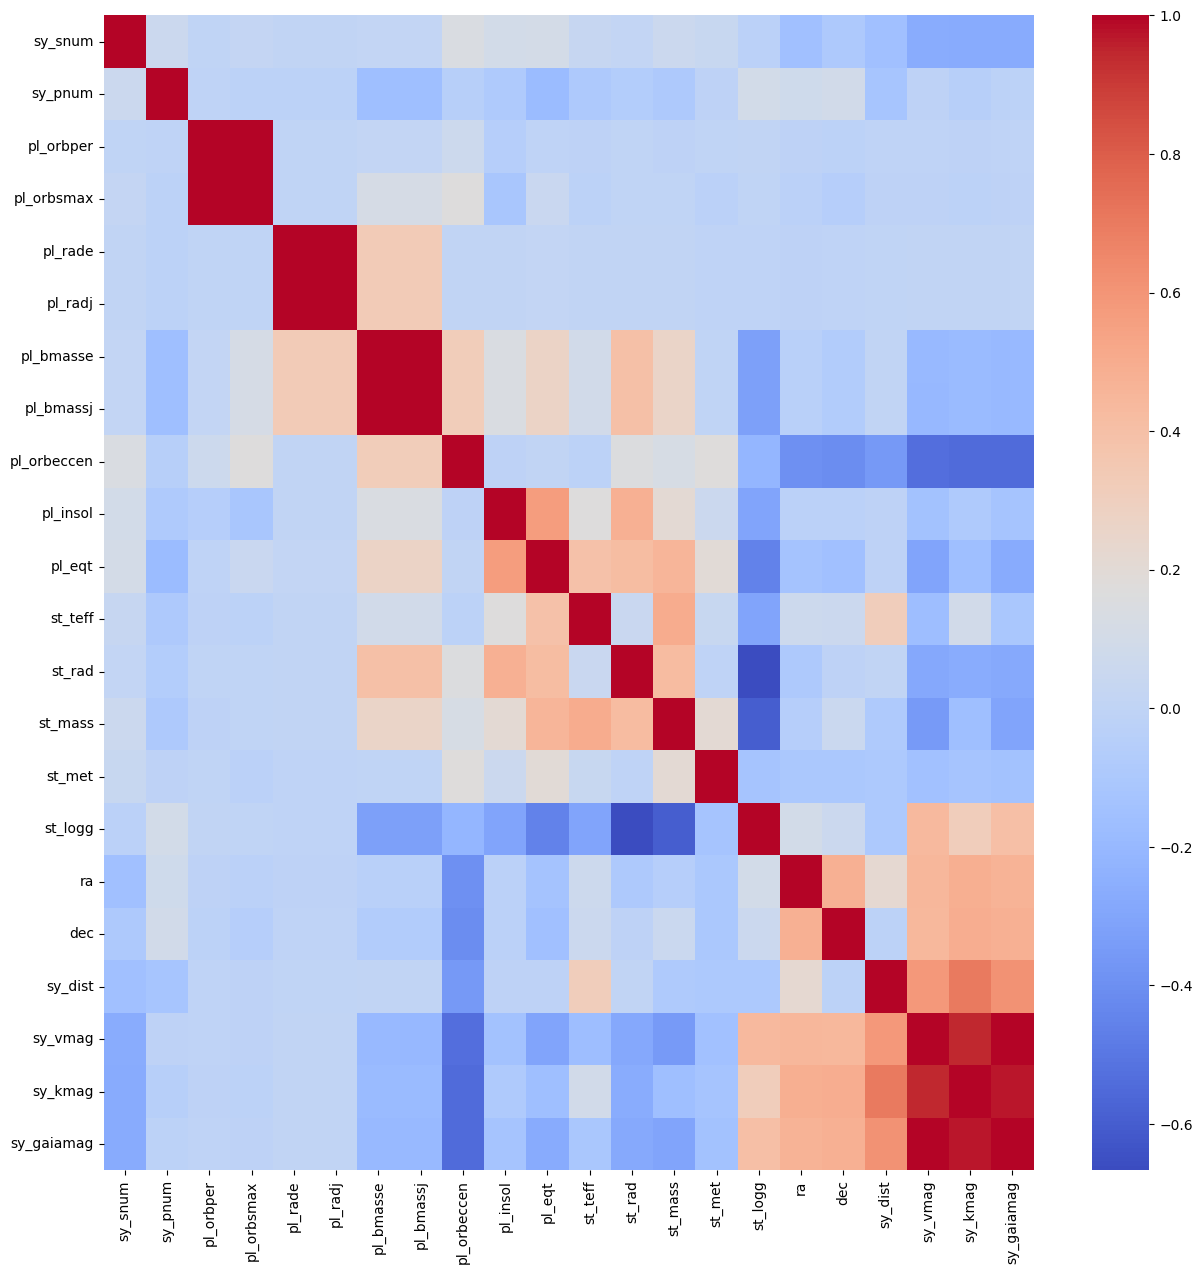

In [ ]:
plot_correlation(df)

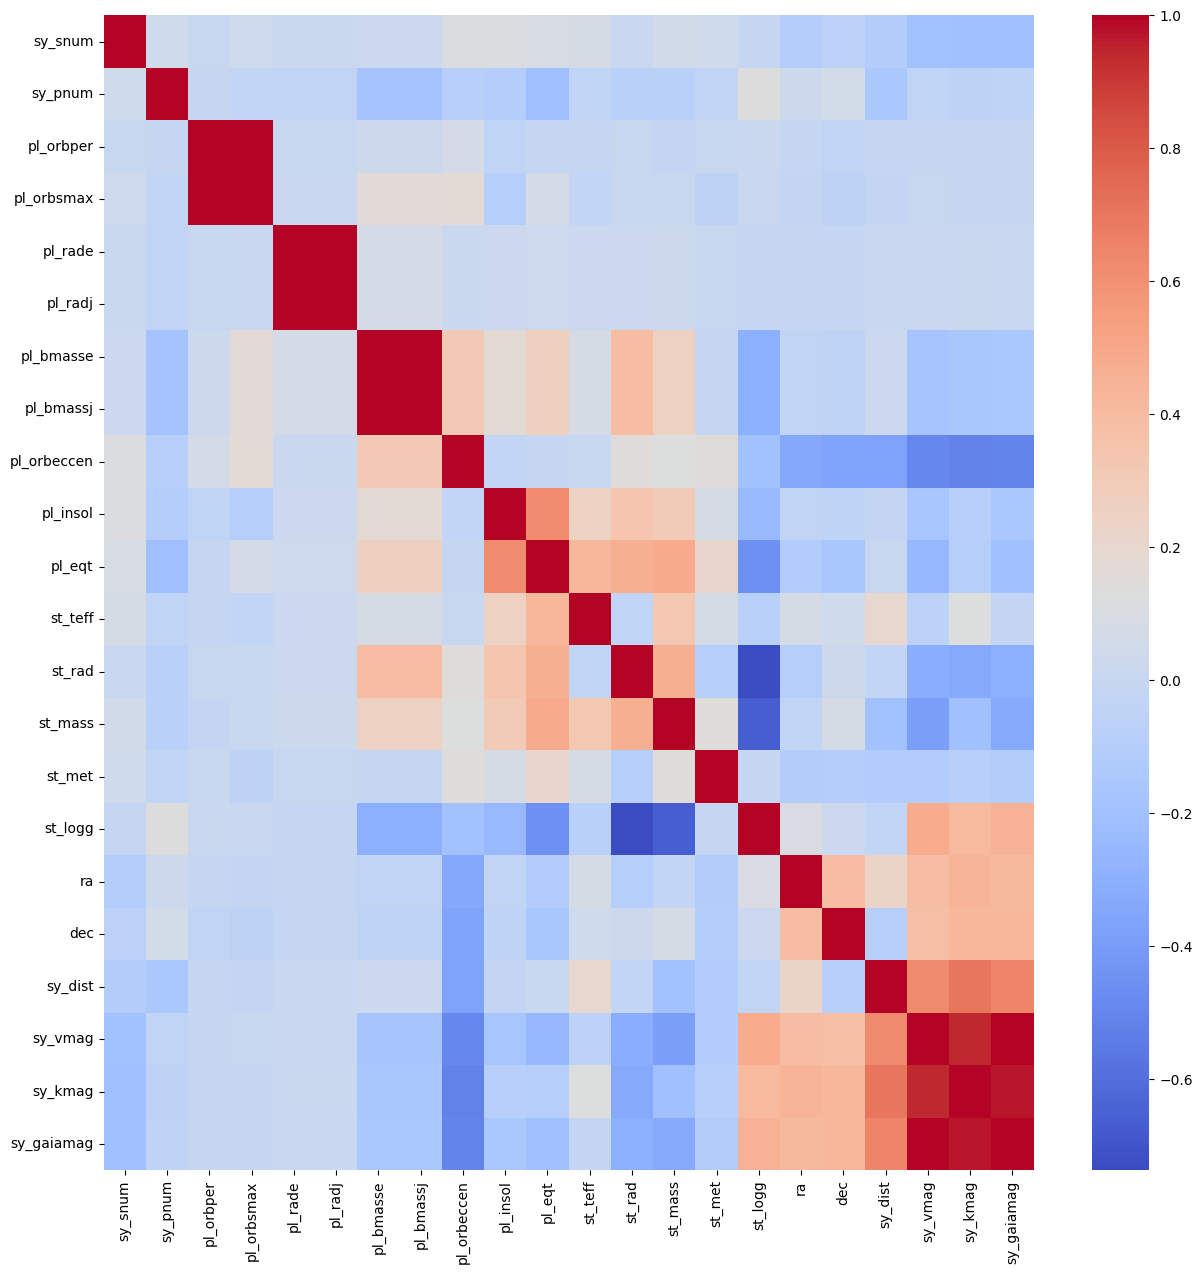

In [ ]:
plot_correlation(aggregated_dataset)

General discussion about the correlations, with connection to tasks. **This cell could be the starting point for the first project discussion with the professors**

**WARNING**: there is a notable difference between the correlation matrix on the original dataset and on the aggregated one. We will consider only the aggregated dataset from this point on:
  * numerical relation between masse and massj (it's just a scaling factor)
  * planet radius and mass are correlated, one could fit a model
  * planet orbital period and planet semi-major axis are strongly correlated (Kepler laws)
  * stellar radius and mass are connected
  * stellar mass and temperature are connected
  * stellar surface gravity (`st_logg`) has strong negative correlation with stellar radius (`st_rad`) and stellar mass (`st_mass`). Gravity follows an inverse-square law based on radius, so as radius (and therefore mass) grow, the surface gravity plummets.

## Clustering occasions
  * planet (radius, mass, insolation flux, equilibrium temperature). We could classify rocky planets vs. gaseous planets and maybe put also the earth values in this plot
  * star (brightness, radius, distance, gravity, metallicity). There is also a string classification that we could use as label for the clustering procedure.

# Below this do what you need to do, I'm operating on top of this cell and I will try to not break anything after

### Discovery methods
Here are the assumptions that are validated by the `check_assumptions` function:
  * all the planets have been measured at least once
  * the same discovery method and discovery facility has been used
  * the number of stars and planets doesn't vary across measurements

The prevalent discovery methods are: transit, radial velocity and microlensing. The other ones have only a handful of samples, so we remove them from the analysis. We are investigating the distribution of a generic target column depending on the discovery method (`plot_distribution`).

The "micro lensing" method is targeted to distant planets but it can't measure the planet radius. A possible question would be to predict the planet radius from the other variables, but we won't have ground truth labels.

It seems that the methods are used on planets of three clusters based on distance. This is an hint that distance may be relevant in the clustering of planets

In [ ]:
def plot_distribution(df, target_column: str, chosen_methods = CHOSEN_DISCOVERY_METHODS, density: bool = False):
    counts = {
        method: []
        for method in chosen_methods
    }

    plt.title(target_column)
    # plt.xscale('log')

    for method in chosen_methods:
        aggregated_on_method = df[df[DISCOVERY_METHOD] == method]

        target = []

        for planet_name, local_df in aggregated_on_method.groupby(PLANET_NAME):
            tmp = local_df[local_df[DEFAULT_FLAG] == 1].iloc[0][target_column]

            if not math.isnan(tmp):
                target.append(tmp)

        if target == []:
            print(f'WARNING: the {method} method has no measure of {target_column}')

        plt.hist(target, label=method, density=density)

    plt.legend()
    plt.show()

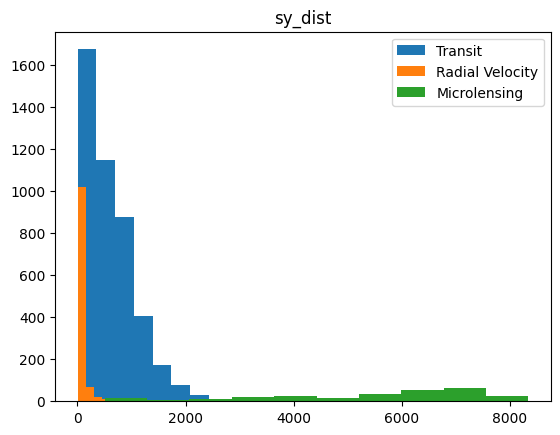

In [ ]:
plot_distribution(df, PLANET_DISTANCE)

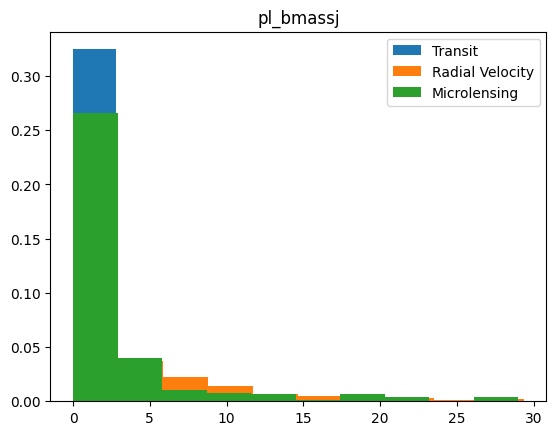

In [ ]:
plot_distribution(df, PLANET_MASS, density=True)

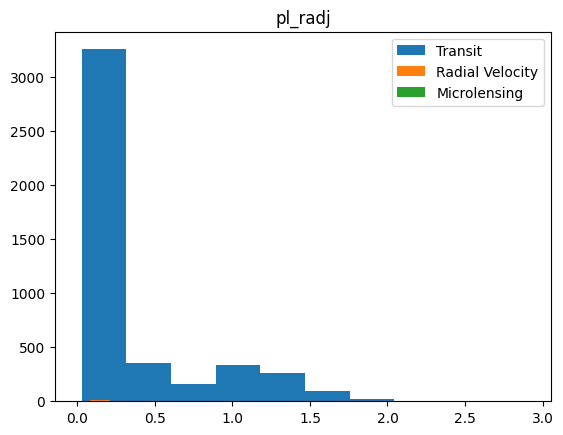

In [ ]:
plot_distribution(df, PLANET_RADIUS)

In [ ]:
np.all(~np.isnan(df[df[DEFAULT_FLAG] == 1][PLANET_RADIUS]))

np.False_

In [ ]:
# TODO: what does mass*sin(i) mean?
# Study every single discovery method

Mass*sin(i)

In [ ]:
df[DISCOVERY_METHOD].unique()

array(['Radial Velocity', 'Imaging', 'Eclipse Timing Variations',
       'Microlensing', 'Transit', 'Transit Timing Variations',
       'Astrometry', 'Disk Kinematics', 'Orbital Brightness Modulation',
       'Pulsation Timing Variations', 'Pulsar Timing'], dtype=object)

In [ ]:
samples_per_planet = []
same_type_measurement = []
same_facility = []

count = 0
for name, local_df in df.groupby(PLANET_NAME):
    samples_per_planet.append(len(local_df[DISCOVERY_METHOD]))
    same_type_measurement.append(len(local_df[DISCOVERY_METHOD].unique()) == 1)
    same_facility.append(len(local_df[DISCOVERY_FACILITY].unique()) == 1)

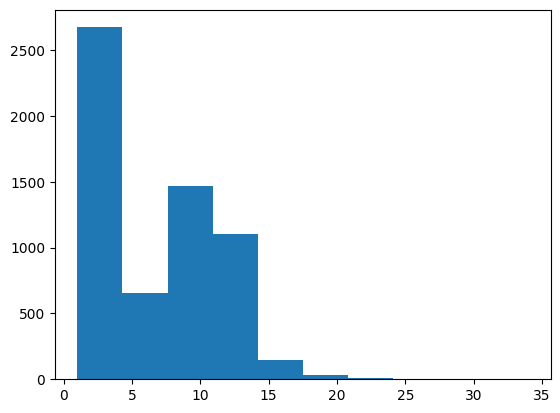

In [ ]:
# TODO: beautify this plot
plt.hist(samples_per_planet)
plt.show()

In [ ]:
# for any planet, only
np.all(same_type_measurement)

np.True_

In [ ]:
np.all(same_facility)

np.True_

In [ ]:
len(df)

39343

In [ ]:
# IMPORTANT: a planet can be measured by multiple instruments
# so the planets names are duplicated
len(df) == len(df[PLANET_NAME].unique())

False

(array([1., 0., 0., 5., 0., 0., 3., 1., 0., 1.]),
 array([0.85  , 0.8665, 0.883 , 0.8995, 0.916 , 0.9325, 0.949 , 0.9655,
        0.982 , 0.9985, 1.015 ]),
 <BarContainer object of 10 artists>)

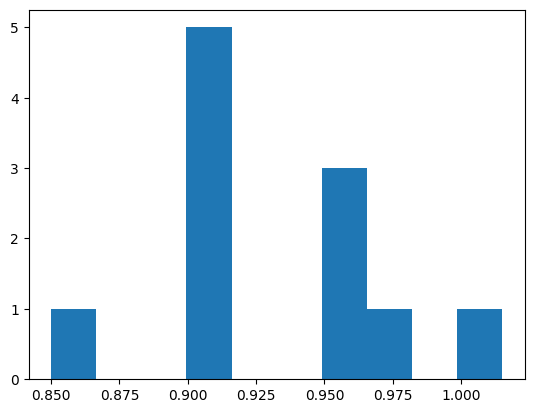

In [ ]:
for name, local_df in df.groupby(PLANET_NAME):
    if len(local_df) > 8:
        break

plt.hist(local_df[STELLAR_MASS])

In [ ]:
local_df[[PLANET_MASS, DEFAULT_FLAG]]

,pl_bmassj,default_flag
78,0.840000,0
79,0.868393,1
80,0.840000,0
81,0.784000,0
82,0.840000,0
83,0.800000,0
84,0.820000,0
85,0.800000,0
86,0.841000,0
87,0.755124,0


(array([17.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  2.]),
 array([0.736539 , 0.9436851, 1.1508312, 1.3579773, 1.5651234, 1.7722695,
        1.9794156, 2.1865617, 2.3937078, 2.6008539, 2.808    ]),
 <BarContainer object of 10 artists>)

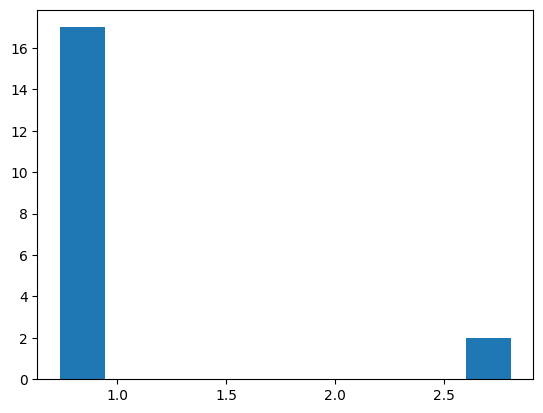

In [ ]:
for name, local_df in df.groupby(PLANET_NAME):
    if len(local_df) > 15:
        break

plt.hist(local_df[PLANET_ORBITAL_PERIOD])

In [ ]:
local_df[[PLANET_ORBITAL_PERIOD, DEFAULT_FLAG, 'pl_orbpererr1', 'pl_orbpererr2']]

,pl_orbper,default_flag,pl_orbpererr1,pl_orbpererr2
114,2.796740,0,1.000000e-04,-1.000000e-04
115,0.736552,0,1.500000e-06,-1.500000e-06
116,0.736546,0,3.000000e-06,-3.000000e-06
117,0.736545,0,1.400000e-06,-1.500000e-06
118,0.736540,0,3.000000e-06,-3.000000e-06
119,0.736547,0,1.700000e-06,-1.700000e-06
120,0.736546,0,8.515900e-07,-8.515900e-07
121,0.736547,1,1.300000e-06,-1.400000e-06
122,2.808000,0,2.000000e-03,-2.000000e-03
123,NaN,0,NaN,NaN


## Rediscovering Kepler's Third Law

To focus on the orbital law, we restrict the analysis to **single-star systems** and to planets with a measured orbital period, semi-major axis and stellar mass.

For a planet orbiting a single star, Kepler's third law can be written as

$$P^2 = \frac{a^3}{M_\star}$$

when we measure:
- $P$ in **years**
- $a$ in **astronomical units (au)**
- $M_\star$ in **solar masses**

These units are convenient because they absorb the physical constants into the proportionality constant, so the relation becomes directly comparable across planetary systems.

To turn this power law into a linear model, we take the base-10 logarithm of both sides:

$$\log_{10}(P^2) = \log_{10}\!\left(\frac{a^3}{M_\star}\right).$$

Using the logarithm identities

$$\log(x^k) = k \log(x), \qquad \log\!\left(\frac{x}{y}\right) = \log(x) - \log(y),$$

we obtain

$$2\log_{10}(P) = 3\log_{10}(a) - \log_{10}(M_\star).$$

Finally, dividing both sides by 2 gives the linear regression form

$$\log_{10}(P) = \frac{3}{2} \log_{10}(a) - \frac{1}{2} \log_{10}(M_\star).$$

This step is crucial for the statistical analysis: once the law is written in log form, the theoretical exponents become the regression coefficients we want to estimate from data. Therefore, in the multiple linear model we expect:
- coefficient of $\log_{10}(a)$ close to $1.5$
- coefficient of $\log_{10}(M_\star)$ close to $-0.5$
- intercept close to $0$

In [ ]:
import statsmodels.api as sm
import scipy.stats as stats
import statsmodels.formula.api as smf

from sklearn.linear_model import LinearRegression, LassoCV, lasso_path
from sklearn.model_selection import KFold, cross_validate
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler

if 'aggregated_dataset' not in globals():
    aggregated_dataset = aggregate_dataset(df)

kepler_columns = [
    # PLANET_NAME,
    # HOST_NAME,
    TOTAL_STARS,
    TOTAL_PLANETS,
    PLANET_ORBITAL_PERIOD,
    'pl_orbsmax',
    'pl_orbeccen',
    'st_mass',
    'st_rad',
    'st_teff',
    'st_met',
]

kepler_df = aggregated_dataset[kepler_columns].copy()
kepler_df = kepler_df[kepler_df[TOTAL_STARS] == 1]
kepler_df = kepler_df.dropna(subset=[PLANET_ORBITAL_PERIOD, 'pl_orbsmax', 'st_mass'])

for column in [PLANET_ORBITAL_PERIOD, 'pl_orbsmax', 'st_mass']:
    kepler_df = kepler_df[kepler_df[column] > 0]

for column in ['st_rad', 'st_teff']:
    kepler_df = kepler_df[(kepler_df[column].isna()) | (kepler_df[column] > 0)]

kepler_df['period_years'] = kepler_df[PLANET_ORBITAL_PERIOD] / 365.25
kepler_df['log_period_years'] = np.log10(kepler_df['period_years'])
kepler_df['log_semimajor_axis'] = np.log10(kepler_df['pl_orbsmax'])
kepler_df['log_stellar_mass'] = np.log10(kepler_df['st_mass'])
kepler_df['log_period_mass_corrected'] = (
    kepler_df['log_period_years'] + 0.5 * kepler_df['log_stellar_mass']
)

kepler_df['log_stellar_radius'] = np.nan
radius_mask = kepler_df['st_rad'].notna()
kepler_df.loc[radius_mask, 'log_stellar_radius'] = np.log10(kepler_df.loc[radius_mask, 'st_rad'])

kepler_df['log_stellar_temperature'] = np.nan
temperature_mask = kepler_df['st_teff'].notna()
kepler_df.loc[temperature_mask, 'log_stellar_temperature'] = np.log10(kepler_df.loc[temperature_mask, 'st_teff'])

summary = pd.Series({
    'total planets after aggregation': len(aggregated_dataset),
    'single-star systems with P, a, M*': len(kepler_df),
    'median stellar mass [M_sun]': kepler_df['st_mass'].median(),
    'median semi-major axis [au]': kepler_df['pl_orbsmax'].median(),
    'median orbital period [days]': kepler_df[PLANET_ORBITAL_PERIOD].median(),
})

display(summary.to_frame(name='value').round(3))

,value
total planets after aggregation,6089.000
"single-star systems with P, a, M*",4938.000
median stellar mass [M_sun],0.959
median semi-major axis [au],0.093
median orbital period [days],11.108


                            OLS Regression Results                            
Dep. Variable:       log_period_years   R-squared:                       0.988
Model:                            OLS   Adj. R-squared:                  0.988
Method:                 Least Squares   F-statistic:                 4.179e+05
Date:                Mon, 15 Jun 2026   Prob (F-statistic):               0.00
Time:                        13:27:12   Log-Likelihood:                 4562.4
No. Observations:                4938   AIC:                            -9121.
Df Residuals:                    4936   BIC:                            -9108.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                         coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------------
const                 -0.0039      0

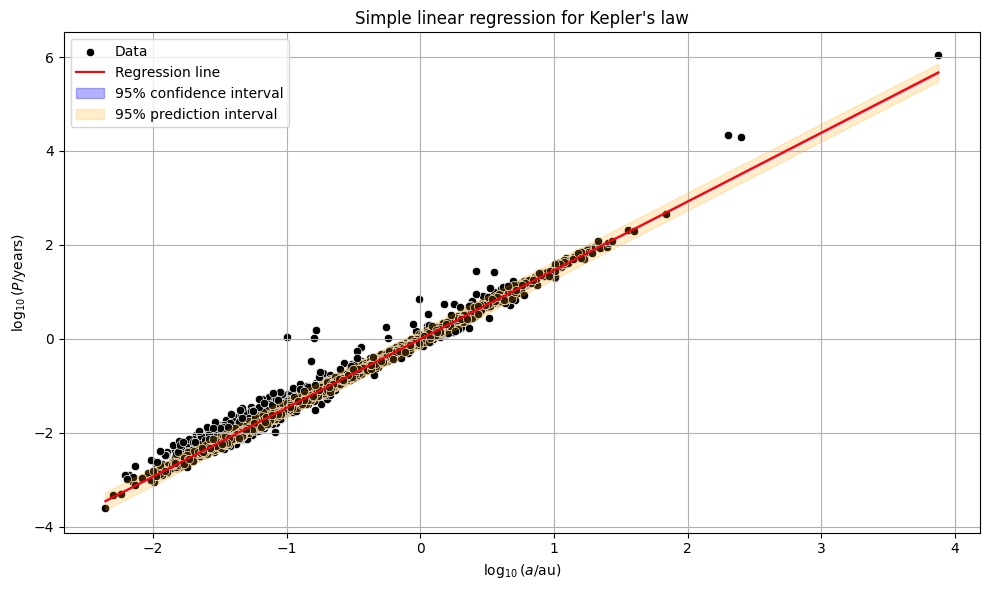

In [ ]:
y = kepler_df['log_period_years']
X_1 = kepler_df[['log_semimajor_axis']]
X_1 = sm.add_constant(X_1)

model_1 = sm.OLS(y, X_1)
results_1 = model_1.fit()
print(results_1.summary())

X_plot = np.linspace(
    kepler_df['log_semimajor_axis'].min(),
    kepler_df['log_semimajor_axis'].max(),
    200,
)
X_plot_df = pd.DataFrame({'log_semimajor_axis': X_plot})
X_plot_const = sm.add_constant(X_plot_df, has_constant='add')

predictions = results_1.get_prediction(X_plot_const)
summary_frame = predictions.summary_frame(alpha=0.05)

y_pred = summary_frame['mean']
ci_lower = summary_frame['mean_ci_lower']
ci_upper = summary_frame['mean_ci_upper']
pi_lower = summary_frame['obs_ci_lower']
pi_upper = summary_frame['obs_ci_upper']

plt.figure(figsize=(10, 6))
sns.scatterplot(
    x=kepler_df['log_semimajor_axis'],
    y=kepler_df['log_period_years'],
    label='Data',
    color='black',
)
plt.plot(X_plot, y_pred, color='red', label='Regression line')
plt.fill_between(X_plot, ci_lower, ci_upper, color='blue', alpha=0.3, label='95% confidence interval')
plt.fill_between(X_plot, pi_lower, pi_upper, color='orange', alpha=0.2, label='95% prediction interval')
plt.xlabel(r'$\log_{10}(a / \mathrm{au})$')
plt.ylabel(r'$\log_{10}(P / \mathrm{years})$')
plt.title("Simple linear regression for Kepler's law")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

                            OLS Regression Results                            
Dep. Variable:       log_period_years   R-squared:                       0.998
Model:                            OLS   Adj. R-squared:                  0.998
Method:                 Least Squares   F-statistic:                 1.013e+06
Date:                Mon, 15 Jun 2026   Prob (F-statistic):               0.00
Time:                        13:27:12   Log-Likelihood:                 8438.3
No. Observations:                4938   AIC:                        -1.687e+04
Df Residuals:                    4935   BIC:                        -1.685e+04
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                         coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------------
const                  0.0030      0

,estimated,theoretical,abs_error
intercept,0.0030,0.0,0.0030
log(a),1.4999,1.5,0.0001
log(M_star),-0.4924,-0.5,0.0076


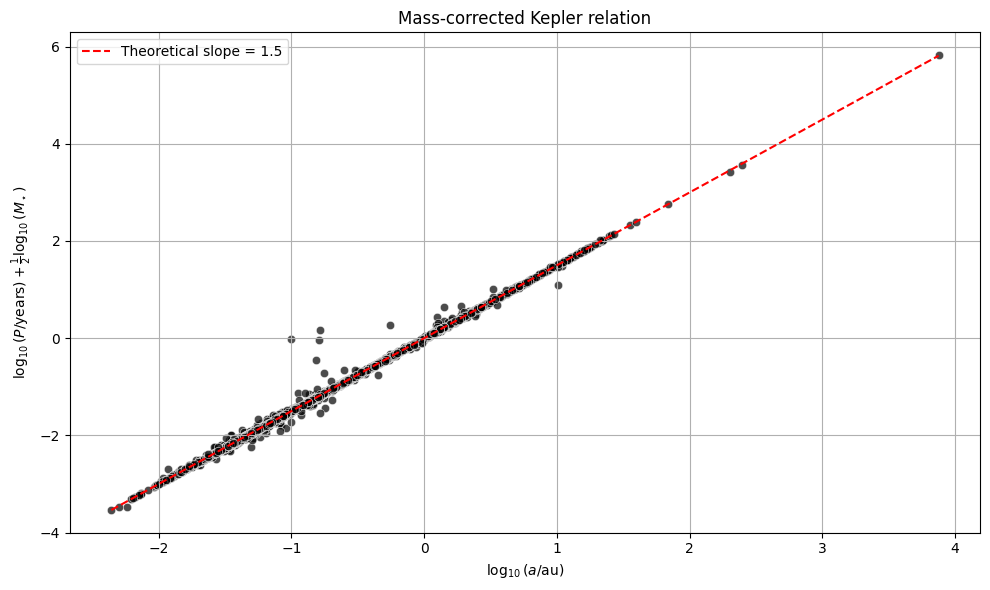

In [ ]:
X_2 = kepler_df[['log_semimajor_axis', 'log_stellar_mass']]
X_2 = sm.add_constant(X_2)

model_2 = sm.OLS(y, X_2)
results_2 = model_2.fit()
print(results_2.summary())

coefficient_comparison = pd.DataFrame({
    'estimated': [
        results_2.params['const'],
        results_2.params['log_semimajor_axis'],
        results_2.params['log_stellar_mass'],
    ],
    'theoretical': [0.0, 1.5, -0.5],
}, index=['intercept', 'log(a)', 'log(M_star)'])
coefficient_comparison['abs_error'] = (
    coefficient_comparison['estimated'] - coefficient_comparison['theoretical']
).abs()

display(coefficient_comparison.round(4))

plt.figure(figsize=(10, 6))
sns.scatterplot(
    x=kepler_df['log_semimajor_axis'],
    y=kepler_df['log_period_mass_corrected'],
    color='black',
    alpha=0.7,
)
plt.plot(X_plot, 1.5 * X_plot, color='red', linestyle='--', label='Theoretical slope = 1.5')
plt.xlabel(r'$\log_{10}(a / \mathrm{au})$')
plt.ylabel(r'$\log_{10}(P / \mathrm{years}) + \frac{1}{2} \log_{10}(M_\star)$')
plt.title('Mass-corrected Kepler relation')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

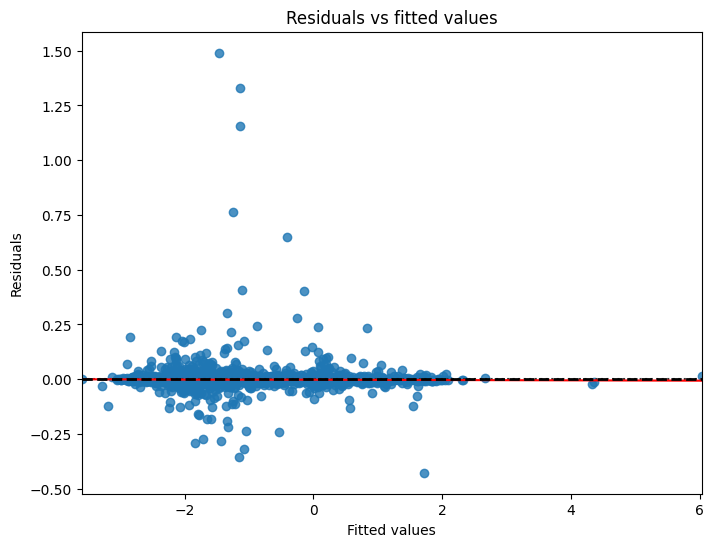

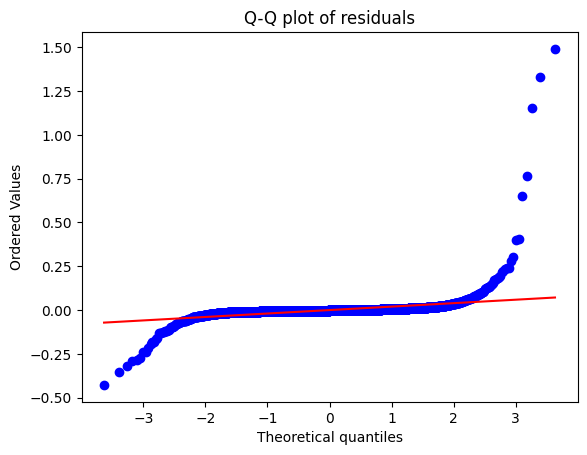

Durbin-Watson statistic: 1.9345
Breusch-Pagan p-value: 0.8463


,Variable,VIF
0,const,3.207
1,log_semimajor_axis,1.062
2,log_stellar_mass,1.062


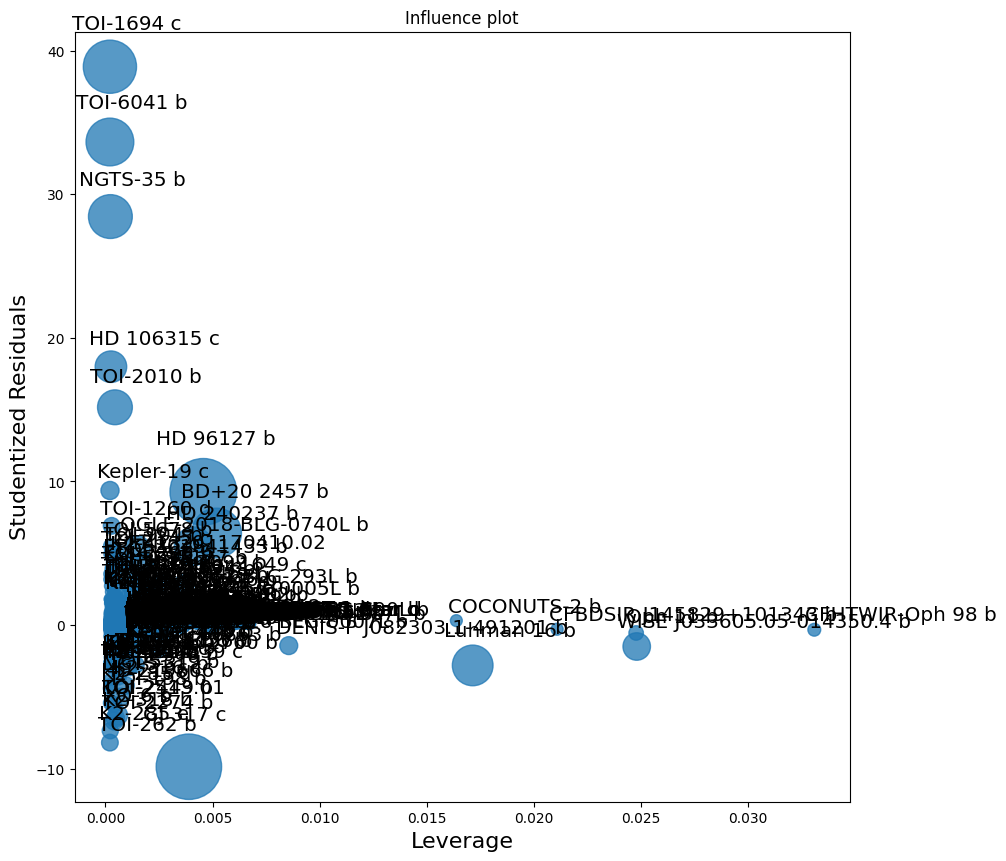

"\ninfluence = results_2.get_influence()\ninfluence_df = influence.summary_frame()[['cooks_d', 'student_resid', 'hat_diag']]\ninfluence_df = influence_df.rename(columns={'cooks_d': 'cooks_distance', 'hat_diag': 'leverage'})\ninfluence_df = pd.concat([\n    kepler_df[[PLANET_NAME, HOST_NAME]].reset_index(drop=True),\n    influence_df.reset_index(drop=True),\n], axis=1).sort_values(by='cooks_distance', ascending=False)\ndisplay(influence_df.head(10).round(4))\n"

In [ ]:
from statsmodels.stats.diagnostic import het_breuschpagan
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.stats.stattools import durbin_watson

fitted_vals = results_2.fittedvalues
residuals = results_2.resid

plt.figure(figsize=(8, 6))
sns.residplot(x=fitted_vals, y=residuals, lowess=True,
              line_kws={'color': 'red', 'lw': 1.5})
plt.axhline(0, color='black', linestyle='--', lw=2)
plt.xlabel('Fitted values')
plt.ylabel('Residuals')
plt.title('Residuals vs fitted values')
plt.show()

stats.probplot(results_2.resid, dist='norm', plot=plt)
plt.title('Q-Q plot of residuals')
plt.show()

print(f'Durbin-Watson statistic: {durbin_watson(results_2.resid):.4f}')

bp_test = het_breuschpagan(results_2.resid, X_2)
print(f'Breusch-Pagan p-value: {bp_test[1]:.4f}')

vif_data = pd.DataFrame()
vif_data['Variable'] = X_2.columns
vif_data['VIF'] = [variance_inflation_factor(X_2.values, i) for i in range(X_2.shape[1])]
display(vif_data.round(4))

fig, ax = plt.subplots(figsize=(10, 10))
sm.graphics.influence_plot(results_2, criterion='cooks', ax=ax)
plt.title('Influence plot')
plt.show()

"""
influence = results_2.get_influence()
influence_df = influence.summary_frame()[['cooks_d', 'student_resid', 'hat_diag']]
influence_df = influence_df.rename(columns={'cooks_d': 'cooks_distance', 'hat_diag': 'leverage'})
influence_df = pd.concat([
    kepler_df[[PLANET_NAME, HOST_NAME]].reset_index(drop=True),
    influence_df.reset_index(drop=True),
], axis=1).sort_values(by='cooks_distance', ascending=False)
display(influence_df.head(10).round(4))
"""

In [ ]:
cv = KFold(n_splits=10, shuffle=True, random_state=42)
X_cv = kepler_df[['log_semimajor_axis', 'log_stellar_mass']]
y_cv = kepler_df['log_period_years']

cv_results = cross_validate(
    LinearRegression(),
    X_cv,
    y_cv,
    cv=cv,
    scoring={'r2': 'r2', 'neg_mse': 'neg_mean_squared_error'},
    return_train_score=False,
)

cv_summary = pd.Series({
    'mean test R^2': cv_results['test_r2'].mean(),
    'std test R^2': cv_results['test_r2'].std(),
    'mean test RMSE': np.sqrt(-cv_results['test_neg_mse']).mean(),
    'std test RMSE': np.sqrt(-cv_results['test_neg_mse']).std(),
})

display(cv_summary.to_frame(name='value').round(4))

,value
mean test R^2,0.9976
std test R^2,0.0022
mean test RMSE,0.0395
std test RMSE,0.0191


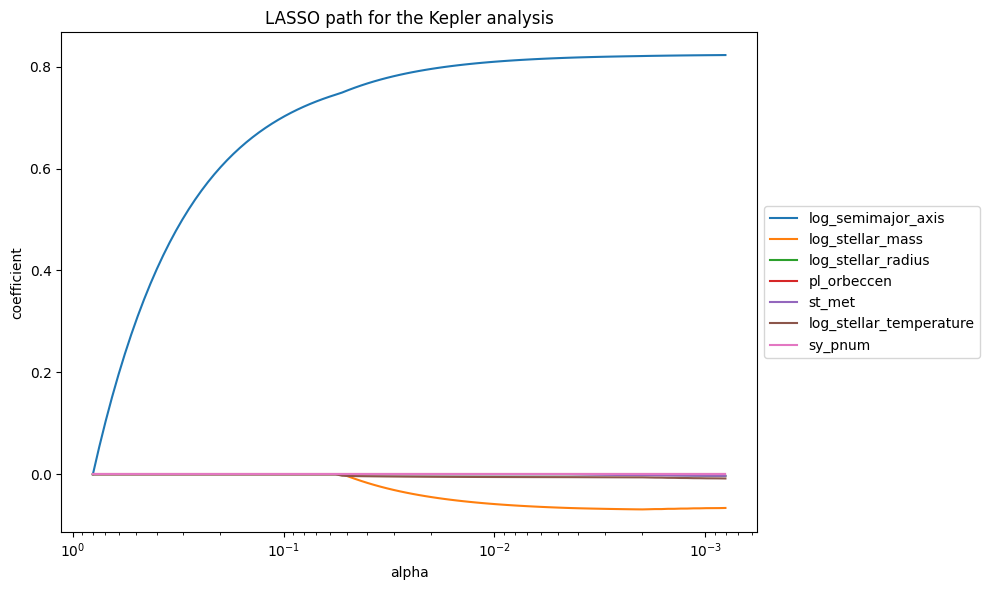

,coefficient
log_semimajor_axis,0.8229
log_stellar_mass,-0.0662
log_stellar_temperature,-0.0084
log_stellar_radius,-0.0035
st_met,-0.0033
pl_orbeccen,0.0000
sy_pnum,0.0000


Selected features at the CV-optimal alpha: ['log_semimajor_axis', 'log_stellar_mass', 'log_stellar_temperature', 'log_stellar_radius', 'st_met']
Optimal alpha: 0.000802


In [ ]:
candidate_features = [
    'log_semimajor_axis',
    'log_stellar_mass',
    'log_stellar_radius',
    'pl_orbeccen',
    'st_met',
    'log_stellar_temperature',
    TOTAL_PLANETS,
]

lasso_df = kepler_df.dropna(subset=['log_period_years'] + candidate_features).copy()
X_lasso = lasso_df[candidate_features]
y_lasso = lasso_df['log_period_years']

X_lasso_scaled = StandardScaler().fit_transform(X_lasso)
alphas, coefficients, _ = lasso_path(X_lasso_scaled, y_lasso.to_numpy())

plt.figure(figsize=(10, 6))
for feature_name, coefficient_path in zip(candidate_features, coefficients):
    plt.plot(alphas, coefficient_path, label=feature_name)

plt.xscale('log')
plt.gca().invert_xaxis()
plt.xlabel('alpha')
plt.ylabel('coefficient')
plt.title('LASSO path for the Kepler analysis')
plt.legend(loc='center left', bbox_to_anchor=(1, 0.5))
plt.tight_layout()
plt.show()

lasso_pipeline = make_pipeline(
    StandardScaler(),
    LassoCV(cv=cv, random_state=42, max_iter=20000),
)
lasso_pipeline.fit(X_lasso, y_lasso)
lasso_model = lasso_pipeline.named_steps['lassocv']

lasso_coefficients = pd.Series(lasso_model.coef_, index=candidate_features)
lasso_coefficients = lasso_coefficients.loc[
    lasso_coefficients.abs().sort_values(ascending=False).index
]
display(lasso_coefficients.to_frame(name='coefficient').round(4))

selected_features = lasso_coefficients[lasso_coefficients.abs() > 1e-3].index.tolist()
print(f'Selected features at the CV-optimal alpha: {selected_features}')
print(f'Optimal alpha: {lasso_model.alpha_:.6f}')

In [ ]:
print('Interpretation')
print(
    f'- In the simple log-log regression, the coefficient of log(a) is {results_1.params["log_semimajor_axis"]:.3f}. '
    f'This is already close to the Kepler value 1.5.'
)
print(
    f'- In the multiple regression, the coefficient of log(a) is {results_2.params["log_semimajor_axis"]:.3f} '
    f'and the coefficient of log(M_star) is {results_2.params["log_stellar_mass"]:.3f}. '
    f'These are very close to the theoretical values 1.5 and -0.5.'
)
print(
    f'- The intercept is {results_2.params["const"]:.4f}, which is also consistent with the expected value 0 '
    f'when the variables are expressed in years, astronomical units and solar masses.'
)
print(
    f'- The 10-fold cross-validated model reaches mean R^2 = {cv_summary["mean test R^2"]:.4f} '
    f'with mean RMSE = {cv_summary["mean test RMSE"]:.4f} in log-years.'
)
print(
    f'- LASSO keeps {selected_features}, so the physically relevant variables remain dominant even when regularization is introduced.'
)

Interpretation
- In the simple log-log regression, the coefficient of log(a) is 1.465. This is already close to the Kepler value 1.5.
- In the multiple regression, the coefficient of log(a) is 1.500 and the coefficient of log(M_star) is -0.492. These are very close to the theoretical values 1.5 and -0.5.
- The intercept is 0.0030, which is also consistent with the expected value 0 when the variables are expressed in years, astronomical units and solar masses.
- The 10-fold cross-validated model reaches mean R^2 = 0.9976 with mean RMSE = 0.0395 in log-years.
- LASSO keeps ['log_semimajor_axis', 'log_stellar_mass', 'log_stellar_temperature', 'log_stellar_radius', 'st_met'], so the physically relevant variables remain dominant even when regularization is introduced.


# Discovering Gravity laws

Looking at the correlation matrix, we notice that `st_logg` (which is the $\log_{10}$ of the stellar surface gravity [log10(cm/s**2)]) has strong negative correlation with, in particular, `st_rad` (stellar radius), and `st_mass` (stellar mass).

This is explained by Gauss's law, which relates the gravitational flux through a closed surface to the mass enclosed within that surface:

$$
  \oint \mathbf g \cdot d \mathbf A = -4 \pi GM
$$

where:

- $\mathbf g$ is the gravitational field vector;
- $d \mathbf A$ is the outward-pointing area vector of an imaginary closed surface (the *Gaussian surface*);
- $G$ is the gravitational constant;
- $M$ is the total mass inside the surface.

When the enclosed surface is just a sphere (star) of mass $M$ and radius $R$, Gauss's law can be elegantly simplified.

Because the star is perfectly spherical, gravity pulls straight inward toward the center everywhere on the surface. However, the area vector $d \mathbf A$ always points outward. Because they point in exactly opposite directions, their dot product introduces a negative sign:

$$
\mathbf g \cdot d \mathbf A = -g d A
$$
$$
\implies \oint - g d A = -4 \pi G M
$$
$$
\implies -g \oint d A = -4 \pi G M
$$

$\oint d A$ is the total surface area of our sphere, which for a sphere of radius $R$ we know is $4 \pi R^2$:

$$
\implies -g \left(4 \pi R^2 \right) = -4 \pi G M
$$
$$
\implies -g R^2 = - GM
$$
$$
\implies g = \frac{GM}{R^2}
$$
This is actually Newton’s law of universal gravitation. From now on, we will just refer to Newton's law for simplicity, but know that by "rediscovering" Gauss's law for our case when the enclosed surface is a sphere, we are actually "also" rediscovering the less general Newton's law.

Now, we want to tackle the problem of building a model to predict $g$, assuming we do not know Newton's law at all. But before doing this, let's see mathematically if it would even be possible to do so with, e.g., a linear model.

Because this relationship is a multiplicative power law, we cannot capture it directly using standard linear modeling. However, by applying a $\log_{10}$ to both sides of the equation, we can linearize it:

$$
\log_{10}{(g)} = \log_{10} { \left( \frac{GM}{R^2} \right) }
$$
$$
\implies \log_{10} (g) = \log_{10}(G) + \log_{10}(M) - 2 \log_{10}(R)
$$

This maps perfectly into a multiple linear regression of the type
$$
Y = \beta_0 + \beta_1 X_1 + \beta_2 X_2 + \varepsilon
$$

where:

- the **target** $Y$ is `st_logg`, which is perfect for us as it is already provided as $\log_{10}(g)$ in the dataset;
- the **intercept** $\beta_0$ is the gravitational constant $G$;
- the **predictor 1** $X_1$ is $\log_{10}($ `st_mass` $)$;
- the **predictor 2** $X_1$ is $\log_{10}($ `st_rad` $)$.

Of course we are assuming that we do not which predictors to use (as there may be other factors influencing the surface gravity) and that we should ideally use $\log_{10}$ of such predictors.

From the correlation matrix we saw deep blue splots in corrispondence of `st_rad` and `st_mass`. Let us plot their raw distributions.

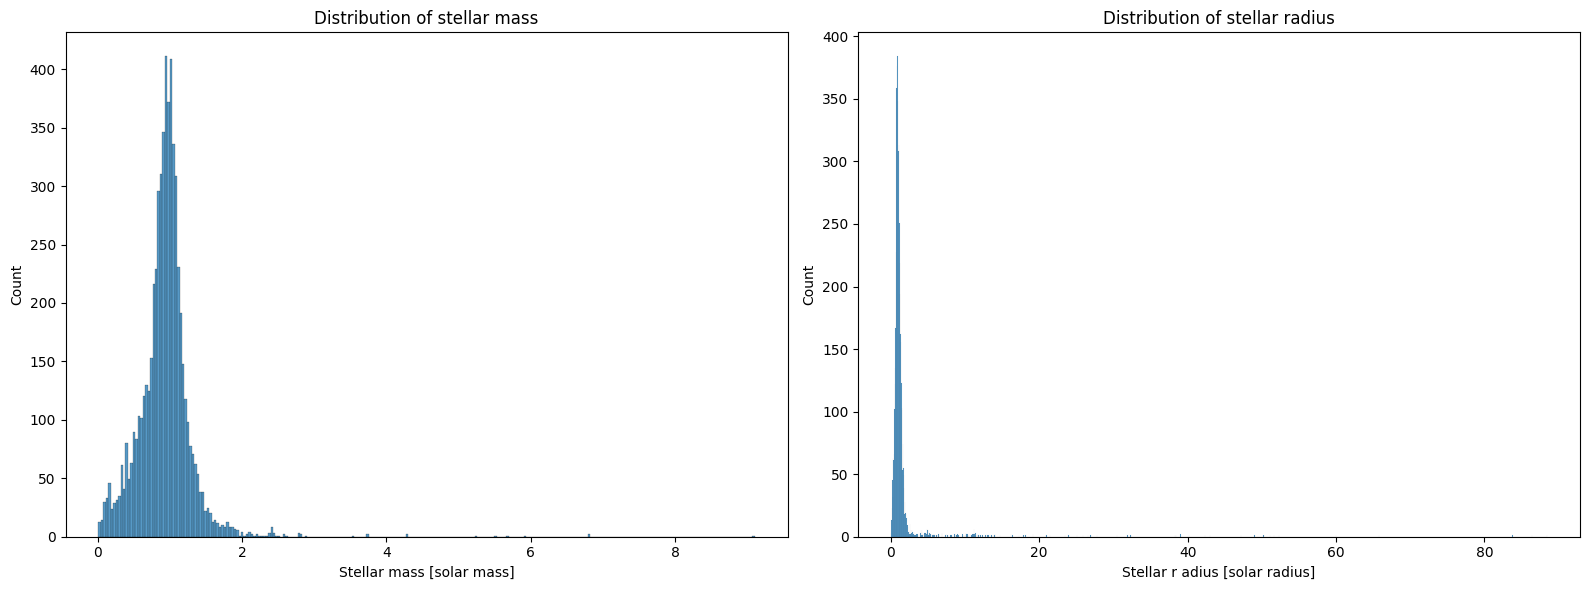

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

sns.histplot(aggregated_dataset["st_mass"], ax=axes[0])
axes[0].set_title('Distribution of stellar mass')
axes[0].set_xlabel('Stellar mass [solar mass]')
axes[0].set_ylabel('Count')

sns.histplot(aggregated_dataset["st_rad"], ax=axes[1])
axes[1].set_title('Distribution of stellar radius')
axes[1].set_xlabel('Stellar r adius [solar radius]')
axes[1].set_ylabel('Count')

plt.tight_layout()
plt.show()

## Data preprocessing

Since we assume we do not know which data fields will influence our target $Y$, we can use feature selection techniques to find out which predictors are actually relevant to predict the target.

We can already drop the columns that are immediately irrelevant to our goal, i.e.:

- Error margins and limits (we are not modeling uncertainty bounds);
- Metadata and flags (not relevant for the purpose of modeling a physical law);
- redundant units (we keep only one unit type, e.g., earth units for the planets);
- Orbital eccentricity (contains too many NaN values);
- Coordinates of the star (we can reasonably assume that the physical law behaves equally anywhere in the universe, we can use `hostname` as unique identifier);
- Planet insolation and equilibrium temperature (they are derived from the star's temperature and the planet's orbital distance anyway).

In [ ]:
# percentage of NaN in those columns
aggregated_dataset[['pl_orbper', 'pl_orbsmax', 'pl_orbeccen']].isnull().mean()

# We can work with 5% of columns being NaN,
# but 15% is a bit much (so we drop it).

,0
pl_orbper,0.053703
pl_orbsmax,0.051568
pl_orbeccen,0.151913


In [ ]:
# We only keep relevant columns
cols_to_keep = [
    # Star data
    'hostname',
    'st_teff',
    'st_rad',
    'st_mass',
    'st_met',
    'st_logg', # Our target

    # Planet data
    'pl_name',
    'pl_orbper',
    'pl_orbsmax',
    'pl_rade',
    'pl_bmasse',


    # System data
    'sy_dist', # distance to earth
    'sy_snum', # num stars in system
    'sy_pnum', # num planets in system
    # How bright the star appears from earth (in different measures)
    # We keep only one as they are correlated
    # (perfect multicollinearity problem)
    # 'sy_vmag',
    # 'sy_kmag',
    'sy_gaiamag', # gaia: modern telescope
    ]

    # add 'hostname' back to the aggregated dataset
star_mapping = df[['pl_name', 'hostname']].drop_duplicates()

# searches for the 'pl_name' and attaches the correct 'hostname' to that row.
df_agg = aggregated_dataset.merge(star_mapping, on='pl_name', how='left')[cols_to_keep]

Since our dataset contains one row per planet (and more than one planet belongs to a single host), and we do not have observations for planets surface gravity, we must exclusively look at the star surface gravity to build our model. Therefore, we must aggregate together all entries belonging to the same star.

In [ ]:
aggregation_rules = {
    # Keep stellar and system properties constant
    # (they are identical for all planets in a system)
    'st_logg': 'first',
    'st_mass': 'first',
    'st_rad': 'first',
    'st_teff': 'first',
    'st_met': 'first',
    'sy_dist': 'first',
    'sy_snum': 'first',
    'sy_pnum': 'first',
    'sy_gaiamag': 'first',

    # Aggregate planetary data into single system traits
    'pl_bmasse': 'sum',   # Total mass of the planetary system
    'pl_rade': 'max',     # Radius of the largest planet (we should not sum here)
    'pl_orbper': 'mean',  # Average orbital period of the system
    'pl_orbsmax': 'max'   # Furthest orbital distance (system boundary)
}

df_agg = df_agg.groupby('hostname').agg(aggregation_rules).reset_index().replace(0, np.nan).dropna()

We cannot assume that the gravitaional law that we want to predict is linear. But since we are using linear models, we must "linearize" our data relationships. To do so we take the $\log_{10}$.

In [ ]:
# Build the predictors dataframe
X_log = pd.DataFrame()

cols_to_log = [
    'st_mass', 'st_rad', 'st_teff', 'sy_dist',
    'pl_bmasse', 'pl_rade', 'pl_orbper', 'pl_orbsmax'
]

cols_to_keep_raw = [
    'st_met', 'sy_gaiamag', 'sy_snum', 'sy_pnum'
]

for col in cols_to_log:
    X_log["log_" + col] = np.log10(df_agg[col])

for col in cols_to_keep_raw:
  X_log[col] = df_agg[col]

y = df_agg["st_logg"] # the target: log10(g)
hostnames = df_agg["hostname"] # just in case we need them

We are ready to start feature selection. We compare different feature selection methods:

1. **Embedded methods**: **Lasso** $L_1$ penalty can shrink irrelevant coefficients to zero;
2. **Wrapper methods**: forward selection, backward elimination, and recursive feature elimination (RFE);
3. Random forest: **feature importance**.

What we are NOT using:

- **Ridge regression**: $L_2$ penalty will shrink coefficients near zero but they will never be zero, which makes it not so relevant for feature selection.
- **PCA** or **Kernel PCA** : while they reduces dimensions, it does so by merging all the original variables together to create a smaller set of new variables. Consequently, these new variables lose their original easy-to-read meaning, which is not ideal when trying to rediscover a readable mathematical equation.
- **t-SNE** or **UMAP**: generally used for clustering.

## Lasso

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LassoCV
from sklearn.metrics import r2_score, mean_squared_error

# split 80% train and 20% test set
X_train, X_test, y_train, y_test = train_test_split(
    X_log, y,
    test_size=0.2,
    random_state=42
)

# Pipeline to prevent data leakage:
# ensures the scaler recalculates on every internal CV fold
lasso_pipe = Pipeline([
    ('scaler', StandardScaler()),
    ('lasso', LassoCV(cv=5, random_state=42, max_iter=10000))
])

# Fit the model only with training data
lasso_pipe.fit(X_train, y_train)

# Extract the coefficients
trained_lasso = lasso_pipe.named_steps['lasso']

print("=== LASSO FEATURE SELECTION RESULTS ===")
print(f"Optimal penalty (alpha) chosen: {trained_lasso.alpha_:.4f}\n")

# Create a clean dataframe of the surviving features
coef_df = pd.DataFrame({
    'Feature': X_log.columns,
    'Coefficient': trained_lasso.coef_
})

# Sort by absolute weight to see the most powerful features at the top
coef_df['Abs_Weight'] = coef_df['Coefficient'].abs()
coef_df = coef_df.sort_values(by='Abs_Weight', ascending=False).drop(columns='Abs_Weight')

print(coef_df.to_string(index=False))

=== LASSO FEATURE SELECTION RESULTS ===
Optimal penalty (alpha) chosen: 0.0007

       Feature  Coefficient
    log_st_rad    -0.364695
   log_st_mass     0.106046
   log_st_teff     0.028019
       sy_pnum     0.003275
 log_pl_bmasse     0.001525
   log_pl_rade    -0.001144
 log_pl_orbper    -0.000343
   log_sy_dist     0.000000
log_pl_orbsmax    -0.000000
        st_met    -0.000000
    sy_gaiamag     0.000000
       sy_snum     0.000000


Since the data is standardized, these coefficients are directly comparable. Therefore, we see that the main features are `log_st_rad` and `log_st_mass`. Another feature that is not that small is `log_st_teff` (effective surface temperature), and it may be worth keeping.

---

**Small digression**: In fact, stars are not static objects, they evolve. According to the Hertzsprung-Russell (HR) diagram, a star's surface temperature is directly linked to its radius and mass depending on what stage of life it is in (Main Sequence, Red Giant, White Dwarf). As a star ages, its temperature drops and its radius increases, which drops its surface gravity. Because of this physical correlation, the algorithm recognized that temperature is a highly proxy indicator for the star's evolutionary state, which in turn predicts its gravity.

---

All other features that have not been removed by Lasso but have very small coefficients ($\leq 0.003$) could be considered as noise.

Let us see how our model performed by testing it against the test set, and then calculatin $R^2$ (the portion of variablity that's successfully captured by our model) and the root mean squared error (RMSE).

In [ ]:
# Test set evaluation: predict the gravity of the 20% unseen stars
y_pred = lasso_pipe.predict(X_test)

r2 = r2_score(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

print("=== TEST SET PERFORMANCE ===")
print(f"R^2: {r2:.4f}")
print(f"RMSE: {rmse:.4f}")

=== TEST SET PERFORMANCE ===
R^2: 0.9666
RMSE: 0.0473


The model achieved an $R^2$ of 0.9666, meaning that 96.66% of the variation in a star's surface gravity is explained by the features in our model (primarily mass and radius). Only 3.4% of the variance is left to unknown noise.

To better understand how good a RMSE of 0.0473 is, we can boxplot our targer variable $y$.

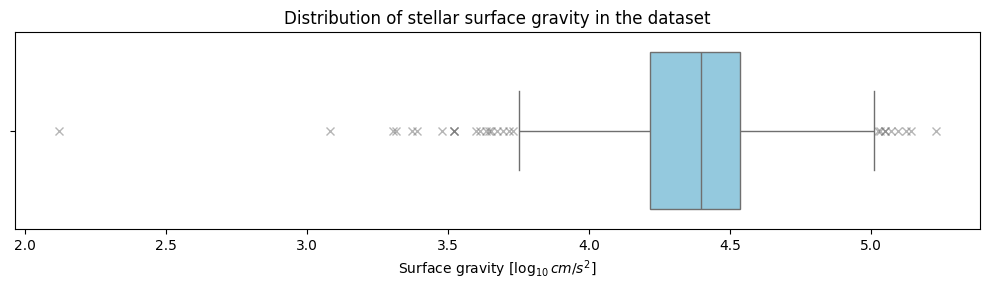

Min(y) = 2.1199999999999997
Max(y) = 5.230325000000001


In [ ]:
plt.figure(figsize=(10, 3))
sns.boxplot(
    x=y,
    color="skyblue",
    flierprops={"marker": "x", "color": "red", "alpha": 0.5} # Highlights outliers
)

plt.title("Distribution of stellar surface gravity in the dataset")
plt.xlabel("Surface gravity [$\\log_{10} cm/s^2$]")
plt.tight_layout()
plt.show()

print(f"Min(y) = {min(y)}")
print(f"Max(y) = {max(y)}")

Even looking at just the minimum and maximum values of $y$, we can see that a RMSE of just 0.0473 is very small compared to the actual values of y.

## Wrapper methods

Let us now see how the other methods that we selecter perform: **forward selection**, **backward elimination**, and **recursive feature elimination (RFE)**.

In [ ]:
import time # calculate elapsed time just for fun
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.feature_selection import SequentialFeatureSelector, RFECV
from sklearn.model_selection import KFold, cross_validate

# === Build the pipelines ===

# we use a base linear regression model for all wrappers
base_linreg = LinearRegression()

# The baseline model using all features
full_pipe = Pipeline([
    ('scaler', StandardScaler()), # data is already preprocessed
    ('model', base_linreg)
])

# Forward selection
forward_pipe = Pipeline([
    ('scaler', StandardScaler()),
    ('select', SequentialFeatureSelector(
        estimator=base_linreg,
        direction='forward',
        n_features_to_select="auto", # let the model decide
        tol = 0.001, # stop if a feature improves R^2 less than 0.001
        scoring='r2',
        cv=5,
        n_jobs=-1
    )),
    ('model', base_linreg)
])

# backward elimination
backward_pipe = Pipeline([
    ('scaler', StandardScaler()),
    ('select', SequentialFeatureSelector(
        estimator=base_linreg,
        direction='backward',
        n_features_to_select="auto", # let the model decide
        # Must be negative as it works the other way around
        tol = -0.001, # stop if a feature DOES NOT improve R^2 less than 0.001
        scoring='r2',
        cv=5,
        n_jobs=-1
    )),
    ('model', base_linreg)
])

# recursive feature elimination (RFE)
rfecv_pipe = Pipeline([
    ('scaler', StandardScaler()),
    ('select', RFECV(
        estimator=base_linreg,
        step=1,
        # Assume gravity could be influenced by just one feature
        min_features_to_select=1,
        scoring='r2',
        cv=5,
        n_jobs=-1
    )),
    ('model', base_linreg)
])

# Bundle them for the loop
pipelines = {
    'Full OLS (all features)': full_pipe,
    'Forward selection': forward_pipe,
    'Backward selection': backward_pipe,
    'Recursive (RFE)': rfecv_pipe
}


# === Cross-Validation evaluation ===

# KFold because gravity is a continuous target
cv = KFold(n_splits=5, shuffle=True, random_state=42)

scoring = {
    'r2': 'r2',
    'neg_mean_squared_error': 'neg_mean_squared_error'
}

cv_results = []

print("Running wrapper methods' CV Loop. This could take a moment...\n")

for name, pipe in pipelines.items():
    start = time.time()

    # Run CV loop
    scores = cross_validate(
        pipe,
        # Assuming X_log has already been split into X_train (run earlier block)
        X_train,
        y_train,
        cv=cv,
        scoring=scoring,
    )

    elapsed = time.time() - start

    # Calculate RMSE from MSE
    rmse_scores = np.sqrt(-scores['test_neg_mean_squared_error'])

    cv_results.append({
        'Model': name,
        'CV R² Mean': scores['test_r2'].mean(),
        'CV R² SD': scores['test_r2'].std(),
        'CV RMSE Mean': rmse_scores.mean(),
        'CV RMSE SD': rmse_scores.std(),
        'Time (s)': elapsed
    })

cv_results_df = pd.DataFrame(cv_results)
print("=== Cross-Validation Predictive Performance ===")
print(cv_results_df.to_string(index=False))
print("\n" + "="*50 + "\n")

# === Feature Extraction ===

# The CV loop above just tests performance. To see which features actually won,
# we must fit the pipelines one final time on the whole training set.

print("=== Wrapper methods' feature selection results ===")
for name, pipe in pipelines.items():
    if 'select' not in pipe.named_steps:
        continue # Full model keeps everything, nothing to select

    # Fit the pipeline
    pipe.fit(X_train, y_train)

    # Extract the boolean mask of winning features from the 'select' step
    support_mask = pipe.named_steps['select'].get_support()
    winning_features = X_train.columns[support_mask].tolist()

    print(f"{name}: {winning_features}")

Running wrapper methods' CV Loop. This could take a moment...

=== Cross-Validation Predictive Performance ===
                  Model  CV R² Mean  CV R² SD  CV RMSE Mean  CV RMSE SD  Time (s)
Full OLS (all features)     0.88556  0.140125      0.081500    0.056812  0.057888
      Forward selection     0.88646  0.140135      0.080993    0.056956  7.145312
     Backward selection     0.88646  0.140135      0.080993    0.056956  9.476460
        Recursive (RFE)     0.88724  0.140339      0.080626    0.057013  0.645929


=== Wrapper methods' feature selection results ===
Forward selection: ['log_st_mass', 'log_st_rad', 'log_st_teff']
Backward selection: ['log_st_mass', 'log_st_rad', 'log_st_teff']
Recursive (RFE): ['log_st_mass', 'log_st_rad', 'log_st_teff']


By setting `n_features_to_select = "auto"` and `tol = 0.001`, we see that we get results comparable to what we found with LASSO (the same three main features to select).

## Random forest

Let us proceed with the last feature selection method that we will be evaluating: Random forest **feature importance**.

=== Random Forest Feature Importance ===
       Feature  Importance (%)
    log_st_rad       87.896176
   log_st_teff        4.224211
   log_st_mass        2.872191
        st_met        1.350079
log_pl_orbsmax        1.062495
   log_sy_dist        0.681543
 log_pl_orbper        0.666014
    sy_gaiamag        0.464067
 log_pl_bmasse        0.327885
   log_pl_rade        0.307362
       sy_pnum        0.102799
       sy_snum        0.045179


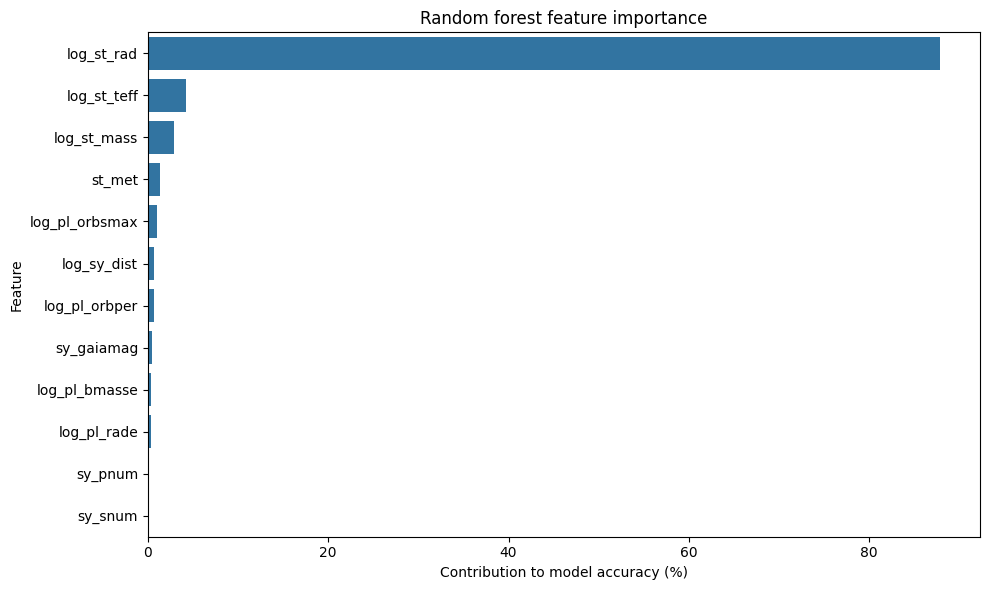

In [ ]:
from sklearn.ensemble import RandomForestRegressor

rf_model = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)
rf_model.fit(X_train, y_train)

# Feature importances (percentages of how much each feature split the trees)
importances = rf_model.feature_importances_

# dataframe just to print the results
rf_results = pd.DataFrame({
    'Feature': X_train.columns,
    'Importance (%)': importances * 100  # Convert to percentage
}).sort_values(by='Importance (%)', ascending=False)

# 4. Print the results
print("=== Random Forest Feature Importance ===")
print(rf_results.to_string(index=False))

# Plot the results
plt.figure(figsize=(10, 6))
sns.barplot(
    data=rf_results,
    x='Importance (%)',
    y='Feature',
)
plt.title("Random forest feature importance")
plt.xlabel("Contribution to model accuracy (%)")
plt.tight_layout()
plt.show()

Note how our random forests put `st_teff` in front of `st_mass`. This is because, mass and temperature are mathematically bound together by the laws of thermodynamics. To the algorithm, `st_mass` and `st_teff` contain almost the same underlying information.

The important thing to note here is that the feature importances are validating what we found with the previous methods (the top 3 predictors), regardless of the order of their importance. **We used this to ensure that we did not miss an importand non-linear relationship that could not be captured by the previous methods**.

## Collinearity (VIF)

To assess how much collinearity is damaging a specific predictor $X_j$, we can calculate the **variable inflation error (VIF)** metric:

$$
VIF_j = \frac{1}{1 - R^2_j}
$$

In [ ]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

# the 3 features we want to test for multicollinearity
features = ['log_st_mass', 'log_st_rad', 'log_st_teff']
data = X_log[features]
# add the constant
data_with_const = sm.add_constant(data)

vif_data = pd.DataFrame()
vif_data["Variable"] = data_with_const.columns
vif_data["VIF"] = [variance_inflation_factor(data_with_const.values, i) for i in range(data_with_const.shape[1])]

# filter out the 'const' row because it is just the y-intercept
print("=== Variance Inflation Factor (VIF) ===")
print(vif_data[vif_data["Variable"] != "const"].to_string(index=False))

=== Variance Inflation Factor (VIF) ===
   Variable       VIF
log_st_mass 14.258335
 log_st_rad  6.796696
log_st_teff  7.186083


this tells us that mass is explained by the other features. At first glance, one might think about removing it (as it is well explained by the other predictors), but VIF only tells us about collinearity, it does NOT tell us that the other features alone can predict the target $Y$ just as well.

Since we now know that one feature might be superfluos, we have to decide which one to remove. If we look back at our LASSO regression, it placed `st_teff` as last place of the three features, so we remove that.

In [ ]:
from sklearn.linear_model import RidgeCV

features_all = ['log_st_mass', 'log_st_rad', 'log_st_teff']
X_ridge = X_log[features_all]

alphas_to_test = np.logspace(-2, 2, 100)
ridge_cv_model = RidgeCV(alphas=alphas_to_test, cv=10)
ridge_cv_model.fit(X_log, y)

# 4. Format and print the coefficients for easy reading
ridge_coefs = pd.DataFrame({
    'Feature': X_log.columns,
    'Ridge_Weight': ridge_cv_model.coef_
})

print(f"=== Ridge Coefficients (Alpha = {ridge_cv_model.alpha_}) ===")
print(ridge_coefs.to_string(index=False))

=== Ridge Coefficients (Alpha = 0.027825594022071243) ===
       Feature  Ridge_Weight
   log_st_mass      0.752356
    log_st_rad     -1.827167
   log_st_teff      0.391198
   log_sy_dist     -0.053351
 log_pl_bmasse      0.004511
   log_pl_rade     -0.009511
 log_pl_orbper     -0.005237
log_pl_orbsmax      0.004788
        st_met     -0.007252
    sy_gaiamag      0.010216
       sy_snum      0.001513
       sy_pnum      0.003159


## Multiple linear regression

Now that we know we must focus only on three features, let's build a multiple linear regression model and evaluate the importance of the coefficients that we find.

In [ ]:
import statsmodels.api as sm

final_features = ['log_st_mass', 'log_st_rad', 'log_st_teff']
X_final = X_log[final_features]
X_final_with_const = sm.add_constant(X_final)

final_model = sm.OLS(y, X_final_with_const).fit()

print(final_model.summary())

                            OLS Regression Results                            
Dep. Variable:                st_logg   R-squared:                       0.887
Model:                            OLS   Adj. R-squared:                  0.886
Method:                 Least Squares   F-statistic:                     3081.
Date:                Mon, 15 Jun 2026   Prob (F-statistic):               0.00
Time:                        13:27:48   Log-Likelihood:                 1169.8
No. Observations:                1185   AIC:                            -2332.
Df Residuals:                    1181   BIC:                            -2311.
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                  coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------
const           3.3266      0.337      9.863      